In [ ]:
from pathlib import Path
import os
import pandas as pd

# Looking for the "data/cleaned" folder.
p = Path.cwd()
project_root = None
for _ in range(10):
    if (p / "data" / "cleaned").exists():
        project_root = p
        break
    p = p.parent

if project_root is None:
    raise FileNotFoundError("Could not find 'data/cleaned' folder in parent.")

print("CWD:", os.getcwd())
print("Project root:", project_root)

CLEAN = project_root / "data" / "cleaned"
OUT = project_root / "reports" / "figures"
OUT.mkdir(parents=True, exist_ok=True)

kpi = pd.read_csv(CLEAN / "trend_kpi_2010_2022.csv")
long = pd.read_csv(CLEAN / "trend_long_2010_2022.csv")

kpi = kpi.sort_values("year")
print("Loaded:", len(kpi), "rows in kpi |", len(long), "rows in long")


CWD: c:\Users\devan\Projects\Pfand-system-analysis\notebooks
Project root: c:\Users\devan\Projects\Pfand-system-analysis
Loaded: 6 rows in kpi | 126 rows in long


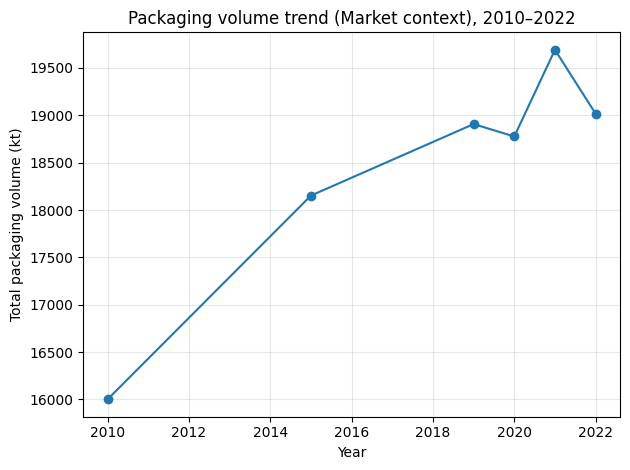

In [5]:
# Total Volume Trend (kt)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(kpi["year"], kpi["total_volume_kt"], marker="o")
plt.xlabel("Year")
plt.ylabel("Total packaging volume (kt)")
plt.title("Packaging volume trend (Market context), 2010–2022")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "layer1_volume_trend_2010_2022.png", dpi=200)
plt.show()


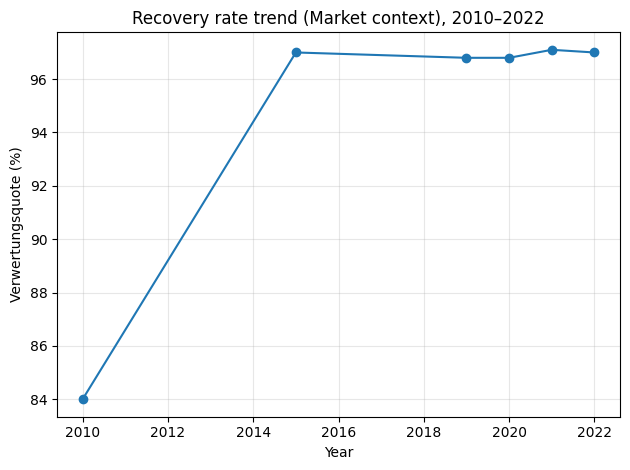

In [ ]:
# Overall Verwertungsquote Trend(%)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(kpi["year"], kpi["verwertungsquote_pct"], marker="o")
plt.xlabel("Year")
plt.ylabel("Verwertungsquote (%)")
plt.title("Recovery rate trend (Market context), 2010–2022")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "layer1_verwertungsquote_trend_2010_2022.png", dpi=200)
plt.show()


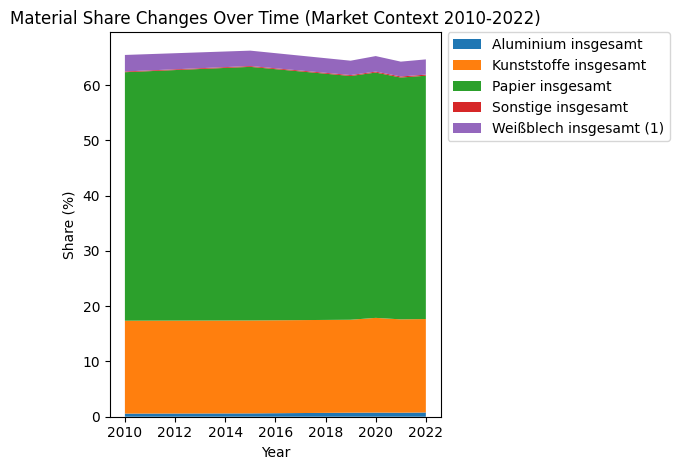

In [11]:
import matplotlib.pyplot as plt
# Filter to parent totals only to avoid double counting
long_totals = long[long["material"].str.contains("insgesamt", case=False, na=False)].copy()
# Pivot to year x material shares
share_pivot = (long_totals.pivot_table(index="year", columns="material", values="share_pct", aggfunc="first").sort_index())
plt.figure()
plt.stackplot(share_pivot.index, share_pivot.T.values, labels=share_pivot.columns)
plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.title("Material Share Changes Over Time (Market Context 2010-2022)")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(OUT / "layer1_material_share_shift_2010_2022.png", dpi=200)
plt.show()
